# **K-Means**
## **Requirements:**
In this practice, you are required to analyze the provided Python code, complete the `TODO` sections, and perform result analysis.  The code applies the K-Means clustering algorithm to the Iris dataset—a well-known dataset in machine learning. The goal is to cluster the data points based on the `petal length (cm)` and `petal width (cm)` features and then map these clusters to the actual species labels to calculate a custom `accuracy`.

### **Deadline:** 5.6



In [84]:
import os
os.environ["OMP_NUM_THREADS"] = '1'
import math
import random
import numpy as np
from sklearn import datasets,cluster
import matplotlib.pyplot as plt

In [85]:
from sklearn.datasets import load_iris
import pandas as pd
# Load Iris data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Check the structure
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


Text(0, 0.5, 'Number')

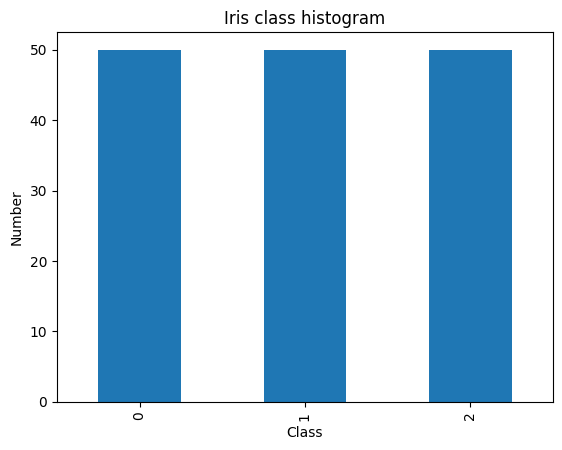

In [87]:
#count_classes = pd.value_counts(data['target'], sort=True).sort_index()
count_classes = pd.Series(df['target']).value_counts().sort_index()
count_classes.plot(kind='bar')
plt.title("Iris class histogram")
plt.xlabel("Class")
plt.ylabel("Number")

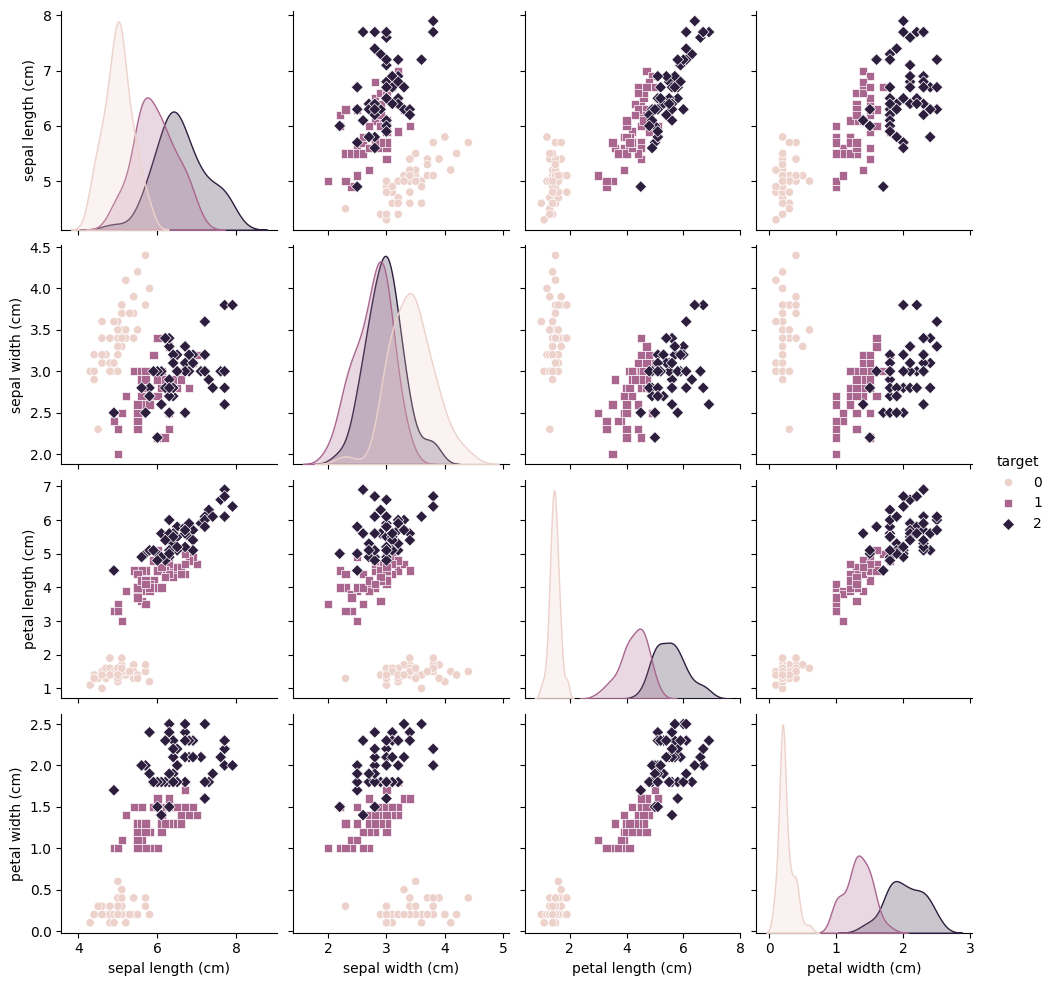

In [88]:
import seaborn as sns
# Pairplot to visualize relationships
sns.pairplot(df, hue="target", markers=["o", "s", "D"])
plt.show()

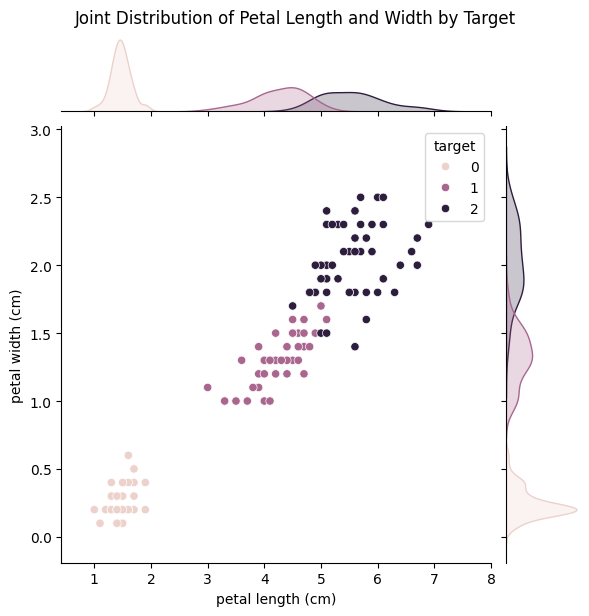

In [89]:
sns.jointplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='target', marker="o")
plt.suptitle('Joint Distribution of Petal Length and Width by Target', y=1.02) 
plt.show()

In [90]:
# using sklearn:https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans
sklearn_kmeans = cluster.KMeans(n_clusters=3, random_state=4307)

#TODO: Fit the model to the data and predict the cluster labels, which are then added to the DataFrame as a new column 'cluster
sklearn_kmeans.fit(df[iris.feature_names])
df['cluster'] = sklearn_kmeans.labels_


#TODO: Get the coordinates of the centroids
centroids = sklearn_kmeans.cluster_centers_


#print
df['cluster'], centroids

(0      1
 1      1
 2      1
 3      1
 4      1
       ..
 145    2
 146    0
 147    2
 148    2
 149    0
 Name: cluster, Length: 150, dtype: int32,
 array([[5.88360656, 2.74098361, 4.38852459, 1.43442623],
        [5.006     , 3.428     , 1.462     , 0.246     ],
        [6.85384615, 3.07692308, 5.71538462, 2.05384615]]))

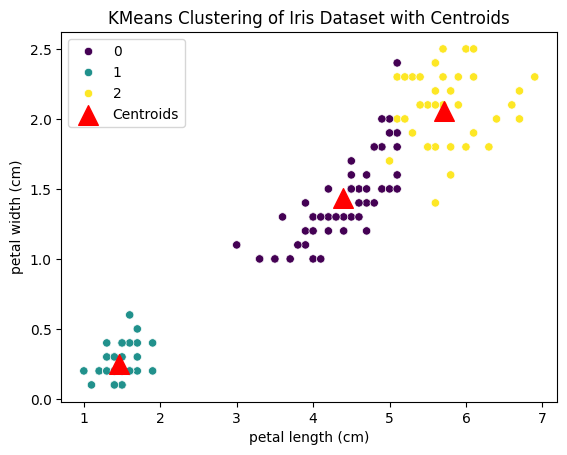

In [91]:
# Use seaborn to plot the scatter plot
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='cluster', palette='viridis')

# Plot the centroids on the scatter plot
plt.scatter(centroids[:, 2], centroids[:, 3], s=200, c='red', marker='^', label='Centroids')

# Add legend and title
plt.legend()
plt.title('KMeans Clustering of Iris Dataset with Centroids')

# Display the plot
plt.show()



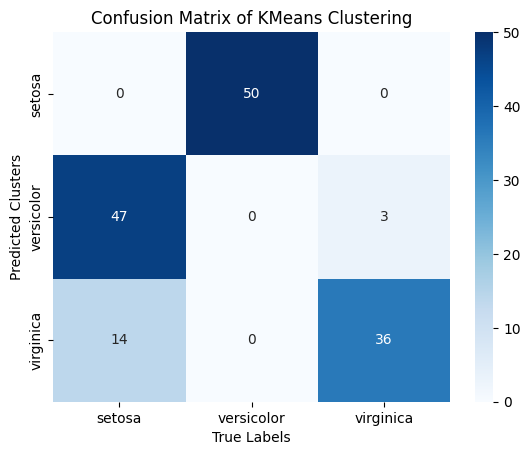

In [92]:
# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(df['target'], df['cluster'])

# Plot the heatmap of the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix of KMeans Clustering')
plt.xlabel('True Labels')
plt.ylabel('Predicted Clusters')
plt.show()

In [93]:
#TODO: Calculate accuracy
from scipy.stats import mode
from sklearn.metrics import accuracy_score
# Since the labels from KMeans might differ from the true labels, we need to map the clustering results to the true labels
# Find the most frequent true label for each cluster. Hint:the mode function should return the most frequent value in the 'target' column for each cluster

labels = np.zeros_like(df['cluster'])
for i in range(3):
    mask = (df['cluster'] == i)
    labels[mask] = mode(df['target'][mask])[0]
accuracy = accuracy_score(df['target'], labels)

print(accuracy)



0.8866666666666667


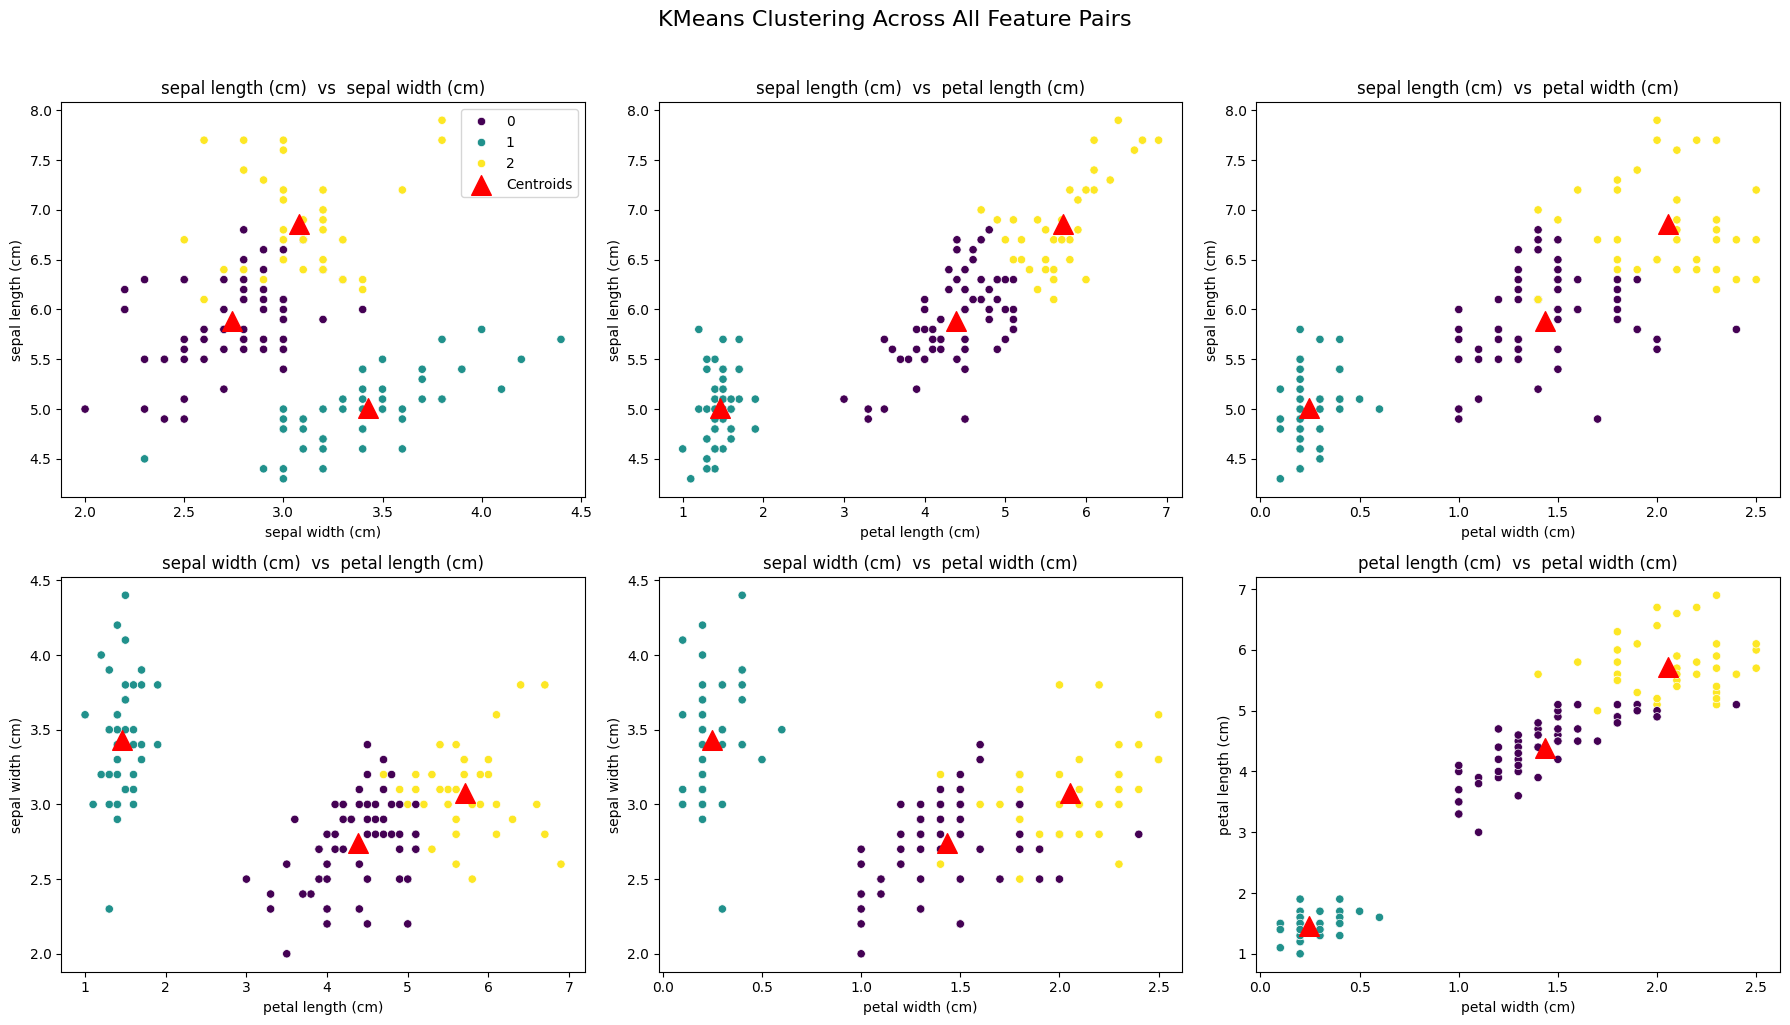

In [94]:
import itertools

features = iris.feature_names
pairs = list(itertools.combinations(range(len(features)), 2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (i, j) in enumerate(pairs):
    ax = axes[idx]
    sns.scatterplot(data=df, x=features[j], y=features[i],
                    hue='cluster', palette='viridis', ax=ax, legend=(idx==0))
    ax.scatter(centroids[:, j], centroids[:, i], s=200, c='red', marker='^', label='Centroids')
    ax.set_title(f'{features[i]}  vs  {features[j]}')
    if idx == 0:
        ax.legend()

plt.suptitle('KMeans Clustering Across All Feature Pairs', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import mode

# 1. 原始数据（你已经跑过的结果）
print(f"Original accuracy: {accuracy:.4f}")

# 2. 标准化后重新聚类
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[iris.feature_names])

kmeans_scaled = cluster.KMeans(n_clusters=3, random_state=4307, n_init=10).fit(X_scaled)
labels_scaled = np.zeros_like(kmeans_scaled.labels_)
for i in range(3):
    mask = (kmeans_scaled.labels_ == i)
    labels_scaled[mask] = mode(df['target'][mask])[0]
acc_scaled = accuracy_score(df['target'], labels_scaled)
print(f"Scaled accuracy:   {acc_scaled:.4f}")

# 3. 多试几个 random_state，看看最好能达到多少
best_acc = 0
best_seed = None
for seed in range(100):
    km = cluster.KMeans(n_clusters=3, random_state=seed, n_init=10).fit(df[iris.feature_names])
    temp_labels = np.zeros_like(km.labels_)
    for i in range(3):
        mask = (km.labels_ == i)
        temp_labels[mask] = mode(df['target'][mask])[0]
    acc = accuracy_score(df['target'], temp_labels)
    if acc > best_acc:
        best_acc = acc
        best_seed = seed

print(f"Best accuracy:     {best_acc:.4f} (random_state={best_seed})")


Original accuracy: 0.8867
Scaled accuracy:   0.8333
Best accuracy:     0.8933 (random_state=0)


PCA(2D) accuracy: 0.8867  (explained variance: 97.77%)
PCA(3D) accuracy: 0.8933  (explained variance: 99.48%)


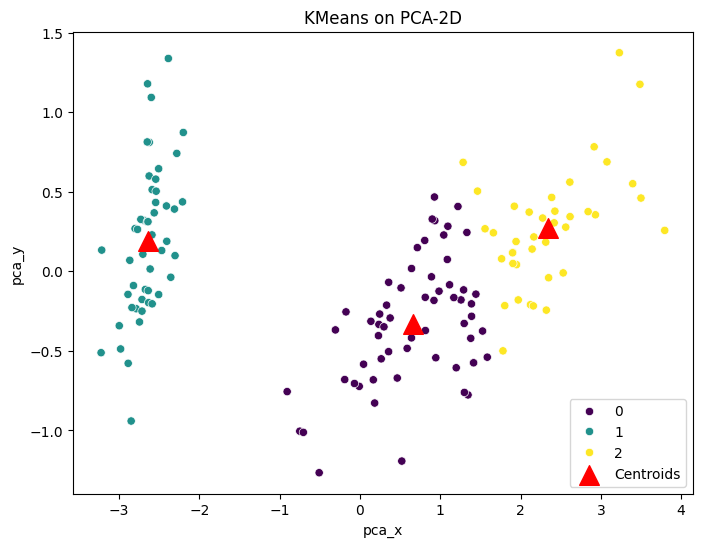

In [96]:
from sklearn.decomposition import PCA

# 对比不同维度的 PCA + KMeans
for n_comp in [2, 3]:
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(df[iris.feature_names])
    
    km_pca = cluster.KMeans(n_clusters=3, random_state=4307, n_init=10).fit(X_pca)
    labels_pca = np.zeros_like(km_pca.labels_)
    for i in range(3):
        mask = (km_pca.labels_ == i)
        labels_pca[mask] = mode(df['target'][mask])[0]
    acc_pca = accuracy_score(df['target'], labels_pca)
    
    print(f"PCA({n_comp}D) accuracy: {acc_pca:.4f}  (explained variance: {pca.explained_variance_ratio_.sum():.2%})")

# 画 PCA-2D 的聚类结果与 centroids
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(df[iris.feature_names])
km_pca2 = cluster.KMeans(n_clusters=3, random_state=4307, n_init=10).fit(X_pca2)

df['pca_x'] = X_pca2[:, 0]
df['pca_y'] = X_pca2[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pca_x', y='pca_y', hue='cluster', palette='viridis')
plt.scatter(km_pca2.cluster_centers_[:, 0], km_pca2.cluster_centers_[:, 1],
            s=200, c='red', marker='^', label='Centroids')
plt.title('KMeans on PCA-2D')
plt.legend()
plt.show()
